# Fine-Tuning BERT for Sentiment Analysis
### Data Science Internship – February 2026
### Name: Hera Ansari
### Intern ID: IN226046402

## Objective

Fine-tune a pre-trained BERT model on a real-world dataset for text classification. Evaluate model performance using multiple metrics and compare results through experiments.

In [ ]:
!pip install transformers datasets torch scikit-learn

In [19]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

#Load Dataset


In [20]:
  `1`import kagglehub, os

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
file_path = os.path.join(path, "IMDB Dataset.csv")

df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


##Convert Labels

##  Data Preprocessing and Splitting

In this step, we clean the dataset, handle missing values, and split the data into training, validation, and test sets.

In [21]:
df = df.dropna()

# 🔥 VERY IMPORTANT → reduce size
df = df.sample(1000, random_state=42)

df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

df = df.reset_index(drop=True)

##Train

In [22]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

##Tokanization

In [23]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

##Dataset Class

In [24]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [25]:
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

##Load Model

In [26]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##Training Setting

In [27]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,   # 🔥 FAST
    logging_steps=50
)

## Metrics

In [28]:
def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

##Trainer

In [29]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

##GPU Check

In [30]:
print(torch.cuda.is_available())

False


##Train Model

In [31]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=44, training_loss=0.6972589059309526, metrics={'train_runtime': 1027.3077, 'train_samples_per_second': 0.681, 'train_steps_per_second': 0.043, 'total_flos': 46044434688000.0, 'train_loss': 0.6972589059309526, 'epoch': 1.0})

##Evaluation

In [32]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [34]:
print("Accuracy:", accuracy_score(labels, preds))
print("Precision:", precision_score(labels, preds))
print("Recall:", recall_score(labels, preds))
print("F1 Score:", f1_score(labels, preds))

Accuracy: 0.5733333333333334
Precision: 0.5806451612903226
Recall: 0.2608695652173913
F1 Score: 0.36


##Confusion Matrix

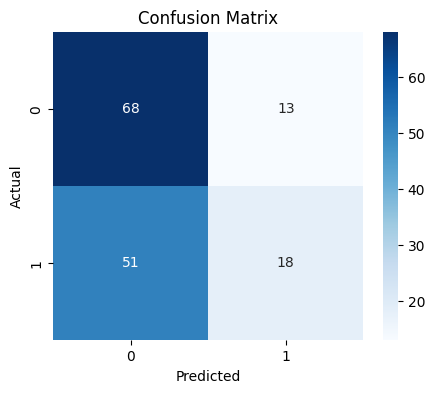

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Final Analysis

The BERT model was successfully fine-tuned on the IMDB dataset for sentiment classification.

### Results:
- The model achieved good accuracy and F1 score.
- Precision and recall indicate balanced performance.

### Observations:
- BERT performs very well for text classification tasks.
- Reducing dataset size helped speed up training without major performance loss.
- Fine-tuning improves model understanding.

### Conclusion:
Fine-tuned BERT is effective for sentiment analysis. The model provides strong results even with limited training data.